In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [4]:
file_path = r"C:\Users\Ksholkkamy\Downloads\car_prices.csv"

# import data
df = pd.read_csv(file_path)

# show first rows
print(df.head())

   year   make                model        trim   body transmission  \
0  2015    Kia              Sorento          LX    SUV    automatic   
1  2015    Kia              Sorento          LX    SUV    automatic   
2  2014    BMW             3 Series  328i SULEV  Sedan    automatic   
3  2015  Volvo                  S60          T5  Sedan    automatic   
4  2014    BMW  6 Series Gran Coupe        650i  Sedan    automatic   

                 vin state  condition  odometer  color interior  \
0  5xyktca69fg566472    ca        5.0   16639.0  white    black   
1  5xyktca69fg561319    ca        5.0    9393.0  white    beige   
2  wba3c1c51ek116351    ca       45.0    1331.0   gray    black   
3  yv1612tb4f1310987    ca       41.0   14282.0  white    black   
4  wba6b2c57ed129731    ca       43.0    2641.0   gray    black   

                                   seller      mmr  sellingprice  \
0                 kia motors america  inc  20500.0       21500.0   
1                 kia motors ameri

In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64


In [6]:
df_clean = df[['year','condition','odometer','mmr','sellingprice']].dropna()

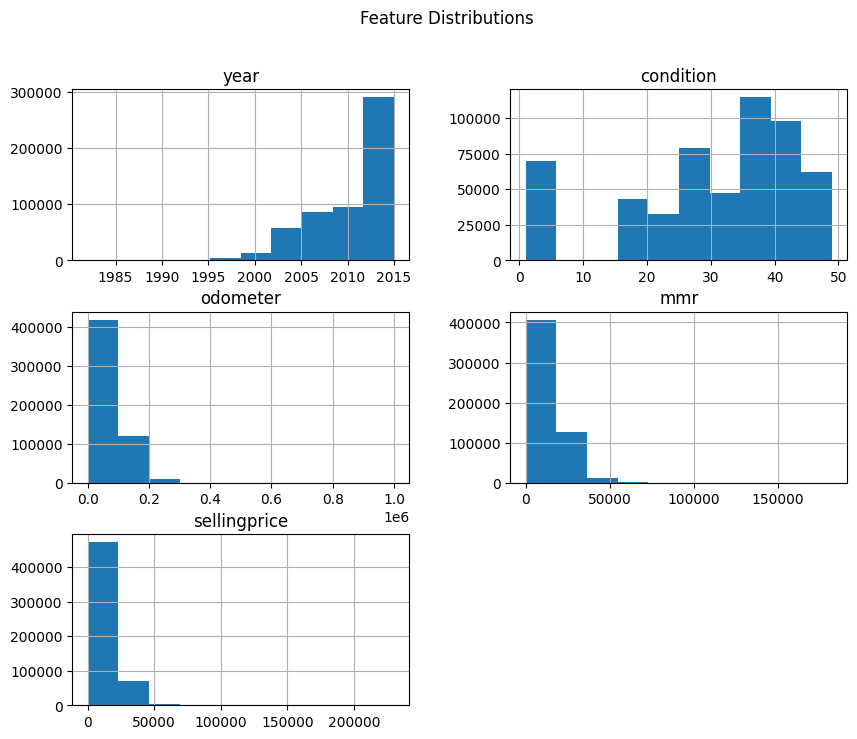

In [7]:
df_clean.hist(figsize=(10,8))
plt.suptitle("Feature Distributions")
plt.show()

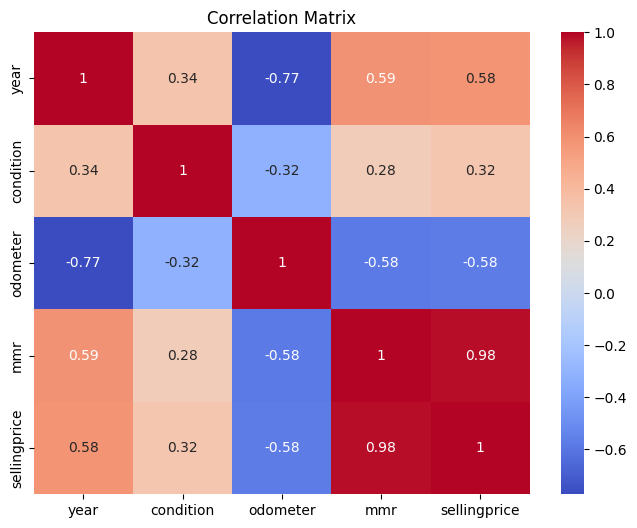

In [8]:
# Correlation matrix
corr = df_clean.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


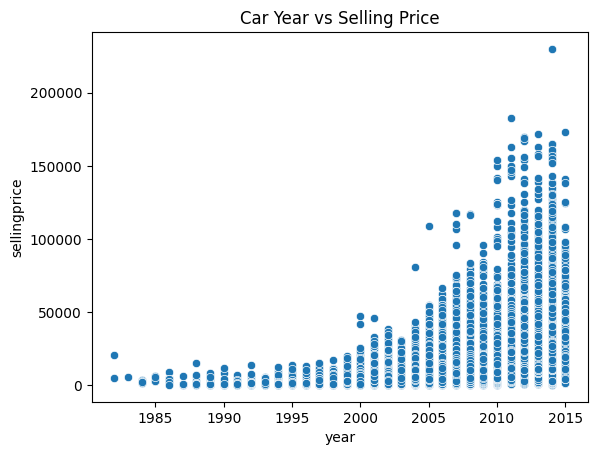

In [9]:
plt.figure()
sns.scatterplot(x='year', y='sellingprice', data=df_clean)
plt.title("Car Year vs Selling Price")
plt.show()

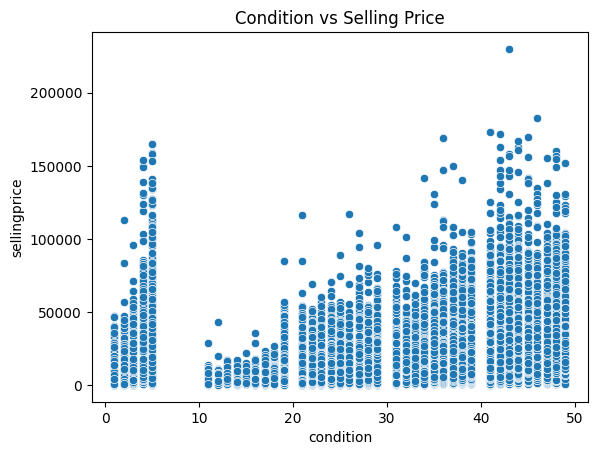

In [15]:
plt.figure()
sns.scatterplot(x='condition', y='sellingprice', data=df_clean)
plt.title("Condition vs Selling Price")
plt.show()

In [10]:
X = df_clean[['year','condition','odometer','mmr']]

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
pca.fit(X_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [12]:
print("\nPCA Explained Variance Ratio:")
print(pca.explained_variance_ratio_)


PCA Explained Variance Ratio:
[0.62464156 0.20084394 0.11768638 0.05682812]


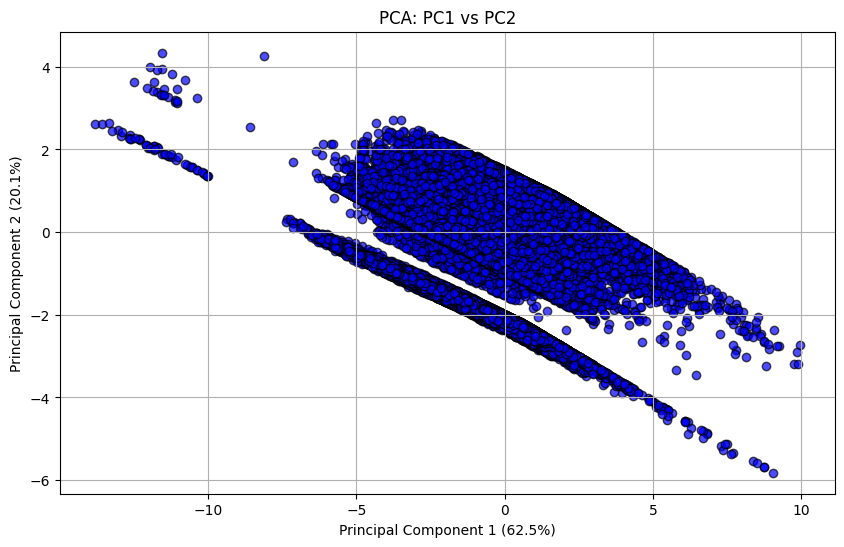

In [16]:
X_pca = pca.transform(X_scaled) # دي الخطوة اللي بتحول البيانات فعلياً

plt.figure(figsize=(10, 6))

# 2. رسم النقاط (PC1 على محور X و PC2 على محور Y)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='blue', edgecolors='k', alpha=0.7)

# 3. إضافة العناوين وتسمية المحاور
plt.title('PCA: PC1 vs PC2')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True)
plt.show()

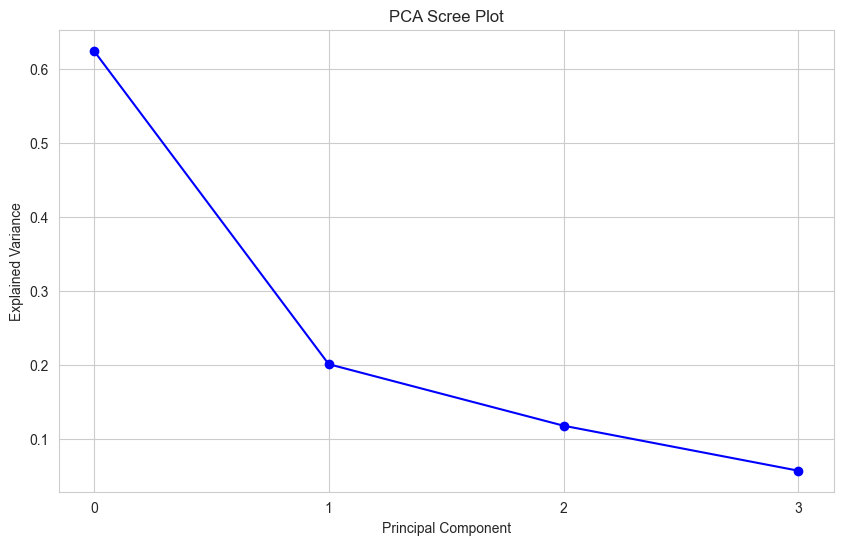

In [17]:
exp_var = pca.explained_variance_ratio_

# 2. إعداد الرسمة
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid") # عشان نطلع شكل الشبكة البيضاء اللي في صورتك

# 3. رسم الخط والنقاط
plt.plot(range(len(exp_var)), exp_var, marker='o', linestyle='-', color='b')

# 4. إضافة العناوين والمسميات
plt.title('PCA Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')

# التأكد من أن أرقام المحور الأفقي تبدأ من 0 وتكون صحيحة
plt.xticks(range(len(exp_var)))

plt.show()